<a href="https://colab.research.google.com/github/pc11837/Linear-Regression/blob/main/Housing_Prediction_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Housing Prices: Develop a regression model to predict house prices based on features like location, size, and amenities.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ML_LAB/Housing_Price_Dataset_120_Records.csv')
df

,HouseID,Location,Area_sqft,Bedrooms,Bathrooms,Balcony,Parking,Age_Years,Furnished,Price
0,H001,Rural,1028,1,3,0,0,5,Yes,55.84
1,H002,Rural,2316,1,4,0,0,3,Yes,103.88
2,H003,Urban,1834,1,2,2,2,23,No,86.42
3,H004,Urban,1719,3,1,0,2,14,No,96.77
4,H005,Suburban,1118,2,3,0,0,13,Yes,63.94
...,...,...,...,...,...,...,...,...,...,...
115,H116,Rural,1624,3,4,1,0,20,Yes,72.72
116,H117,Suburban,2304,3,3,0,0,8,Yes,110.52
117,H118,Rural,2482,3,1,0,1,17,No,86.06
118,H119,Suburban,1171,4,4,0,1,12,No,88.73


In [ ]:
df_ml = df.drop(columns=['HouseID'])
df_ml['Furnished'] = df_ml['Furnished'].map({'Yes': 1, 'No': 0})
df_ml = pd.get_dummies(df_ml, columns=['Location'], drop_first=True)

In [ ]:
X = df_ml.drop(columns=['Price'])
y = df_ml['Price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 3.927265130552285e-26


Text(0, 0.5, 'Predicted Price')

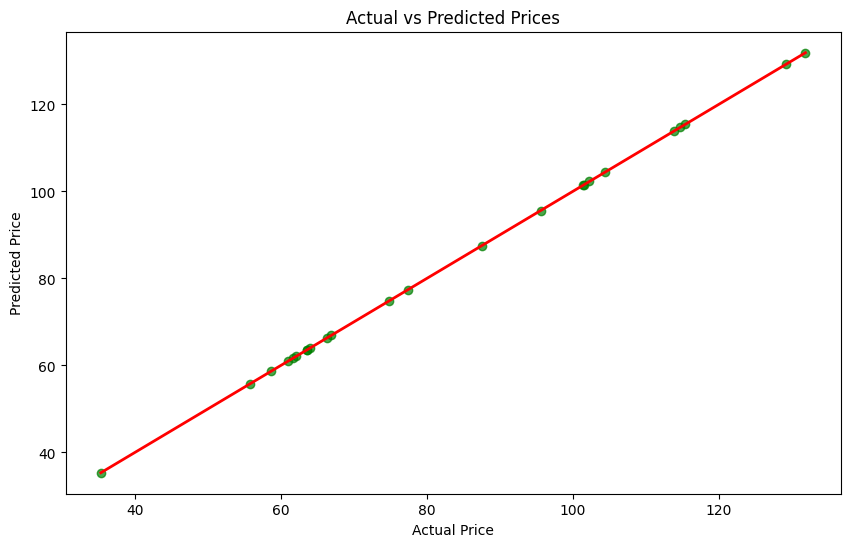

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

In [ ]:
import pickle
import os

In [ ]:
folder_path = '/content/drive/MyDrive/ML_LAB'
model_save_path = os.path.join(folder_path, 'house_price_model.pkl')

In [ ]:
with open(model_save_path, 'wb') as model_file:
    pickle.dump(model, model_file)